In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print(PROJECT_ROOT)
print(DATA_PROCESSED)

c:\Users\karol\Desktop\esp_industrial_ml
c:\Users\karol\Desktop\esp_industrial_ml\data\processed


In [2]:
processed_files = list(DATA_PROCESSED.glob("*.parquet"))

print(processed_files)

df = pd.read_parquet(processed_files[0])

print(df.shape)
df.head()

[WindowsPath('c:/Users/karol/Desktop/esp_industrial_ml/data/processed/dataset_clean.parquet')]
(217781, 77)


,008A00444,008A00936,008A00910,008A00911,008A00720,008A00728,008A02273,008A02274,008A02275,008A00719,008A00727,008A01350,008A01341,008A01343,008A01347,008A01345,008A02118,016A00219,008A00723,016A00396,008A00731,008A01353,008B01474,008B01479,008B01484,008B01489,source_file,008A00741,008A00742,008B05167,008A02270,008A02292,008B05155,008A02267,008A02289,008A02264,008B05146,008B05131,008B05140,008A02276,008A02277,008B05100,008B05103,008A02282,008A02283,008B05173,008A02271,008A02293,008A02268,008A02290,008A02265,008B05150,008B05135,008A02278,008B05106,008A02284,008A02279,008B05109,008A02285,008B05178,008A02272,008A02294,008A02269,008A02291,008A02266,008B05154,008B05139,008A02280,008B05112,008A02286,008A02281,008B05115,008A02287,008B05096,008B05121,008B05126,008B05117
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,186.0,32.500000,68282.0,73877.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,11.0,4.9,137.0,13.0,149.0,14.0,146.0,0.0,0.0,0.0,0.0,1.xls,5.1,8.9,1.0,266.0,390.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,212.0,392.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,212.0,388.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:10,186.0,31.700001,68103.0,73804.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,11.0,4.9,137.0,13.0,149.0,13.0,146.0,0.0,0.0,0.0,0.0,1.xls,5.1,9.0,1.0,266.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,211.0,393.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,214.0,388.0,301.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:20,186.0,32.000000,68766.0,73499.0,124.0,126.0,14.0,12.1,11.3,-0.63,-0.55,8.2,1308.0,174.0,44.0,11.0,4.9,136.0,13.0,149.0,13.0,151.0,0.0,0.0,0.0,0.0,1.xls,5.1,9.1,1.0,267.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,86.0,1.0,214.0,391.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,217.0,385.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:30,186.0,31.799999,68103.0,73645.0,124.0,126.0,13.8,11.8,11.2,-0.63,-0.55,8.2,1308.0,174.0,44.0,11.0,4.9,136.0,13.0,149.0,14.0,151.0,0.0,0.0,0.0,0.0,1.xls,5.2,9.0,1.0,266.0,389.0,1.0,294.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,209.0,393.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,214.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:40,186.0,32.400002,68209.0,73645.0,125.0,126.0,14.0,11.9,11.2,-0.63,-0.54,8.2,1313.0,173.0,45.0,9.0,4.9,136.0,13.0,149.0,14.0,150.0,0.0,0.0,0.0,0.0,1.xls,5.2,9.1,1.0,269.0,389.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,207.0,394.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,209.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,87.0,0.0,32.0,1.0,1.0,1.0,1.0


In [3]:
print(type(df.index))
print(df.index.min())
print(df.index.max())
print(df.index.to_series().diff().value_counts().head())

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2025-06-30 00:00:00
2025-08-01 00:00:00
timestamp
0 days 00:00:10    217775
0 days 00:19:30         1
2 days 01:05:20         1
2 days 07:27:20         1
2 days 09:47:10         1
Name: count, dtype: int64


In [4]:
df.columns.tolist()

['008A00444',
 '008A00936',
 '008A00910',
 '008A00911',
 '008A00720',
 '008A00728',
 '008A02273',
 '008A02274',
 '008A02275',
 '008A00719',
 '008A00727',
 '008A01350',
 '008A01341',
 '008A01343',
 '008A01347',
 '008A01345',
 '008A02118',
 '016A00219',
 '008A00723',
 '016A00396',
 '008A00731',
 '008A01353',
 '008B01474',
 '008B01479',
 '008B01484',
 '008B01489',
 'source_file',
 '008A00741',
 '008A00742',
 '008B05167',
 '008A02270',
 '008A02292',
 '008B05155',
 '008A02267',
 '008A02289',
 '008A02264',
 '008B05146',
 '008B05131',
 '008B05140',
 '008A02276',
 '008A02277',
 '008B05100',
 '008B05103',
 '008A02282',
 '008A02283',
 '008B05173',
 '008A02271',
 '008A02293',
 '008A02268',
 '008A02290',
 '008A02265',
 '008B05150',
 '008B05135',
 '008A02278',
 '008B05106',
 '008A02284',
 '008A02279',
 '008B05109',
 '008A02285',
 '008B05178',
 '008A02272',
 '008A02294',
 '008A02269',
 '008A02291',
 '008A02266',
 '008B05154',
 '008B05139',
 '008A02280',
 '008B05112',
 '008A02286',
 '008A02281',
 '00

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217781 entries, 2025-06-30 00:00:00 to 2025-08-01 00:00:00
Data columns (total 77 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   008A00444    217781 non-null  float64
 1   008A00936    217781 non-null  float64
 2   008A00910    217781 non-null  float64
 3   008A00911    217781 non-null  float64
 4   008A00720    217781 non-null  float64
 5   008A00728    217781 non-null  float64
 6   008A02273    217781 non-null  float64
 7   008A02274    217781 non-null  float64
 8   008A02275    217781 non-null  float64
 9   008A00719    217781 non-null  float64
 10  008A00727    217781 non-null  float64
 11  008A01350    217781 non-null  float64
 12  008A01341    217781 non-null  float64
 13  008A01343    217781 non-null  float64
 14  008A01347    217781 non-null  float64
 15  008A01345    217781 non-null  float64
 16  008A02118    217781 non-null  float64
 17  016A00219    210644 non-null  flo

In [6]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

016A00396    7137
016A00219    7137
008B05103       2
008B05100       2
008B05146       2
008B05167       2
008B05155       2
008B01484       2
008B01489       2
008B01474       2
008B01479       2
008B05140       2
008B05131       2
008B05139       2
008B05112       2
008B05154       2
008B05117       2
008B05096       2
008B05121       2
008B05126       2
008B05115       2
008B05106       2
008B05109       2
008B05178       2
008B05173       2
008B05135       2
008B05150       2
dtype: int64

In [7]:
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_percent
016A00219,7137,3.277145
016A00396,7137,3.277145
008B05140,2,0.000918
008B05139,2,0.000918
008B05155,2,0.000918
008B05126,2,0.000918
008B05121,2,0.000918
008B05178,2,0.000918
008B05117,2,0.000918
008B05100,2,0.000918


In [8]:
cols_with_many_missing = ["016A00396", "016A00219"]

for col in cols_with_many_missing:
    missing_idx = df.index[df[col].isna()]
    
    print("\n", col)
    print("Number of missing:", len(missing_idx))
    print("First missing:", missing_idx.min())
    print("Last missing:", missing_idx.max())


 016A00396
Number of missing: 7137
First missing: 2025-07-01 11:57:00
Last missing: 2025-07-26 10:26:20

 016A00219
Number of missing: 7137
First missing: 2025-07-01 11:57:00
Last missing: 2025-07-26 10:26:20


In [9]:
df[["016A00396", "016A00219"]].isna().value_counts()


016A00396  016A00219
False      False        210644
True       True           7137
Name: count, dtype: int64

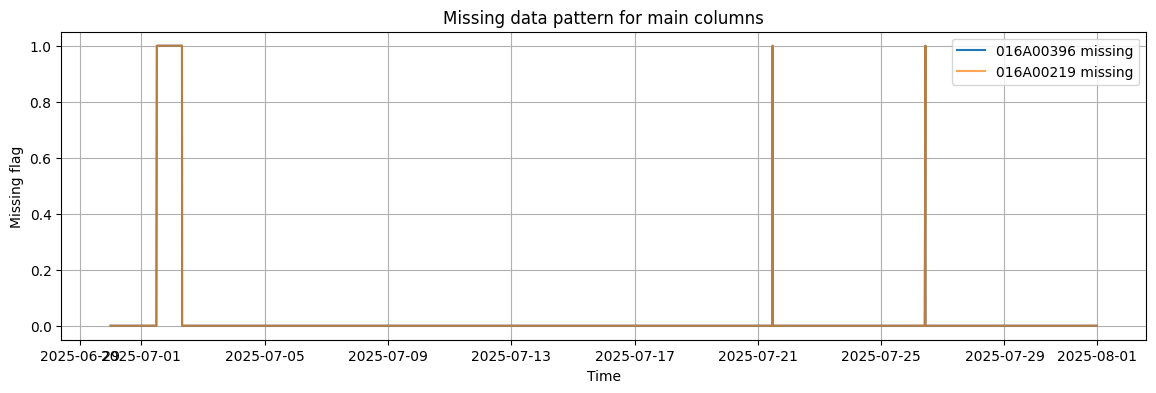

In [10]:
plt.figure(figsize=(14, 4))

plt.plot(df.index, df["016A00396"].isna().astype(int), label="016A00396 missing")
plt.plot(df.index, df["016A00219"].isna().astype(int), label="016A00219 missing", alpha=0.7)

plt.title("Missing data pattern for main columns")
plt.xlabel("Time")
plt.ylabel("Missing flag")
plt.legend()
plt.grid(True)
plt.show()

Tag mapping

In [11]:
TAG_MAPPING_PATH = DATA_PROCESSED / "tag_mapping.csv"

tag_map = pd.read_csv(TAG_MAPPING_PATH, sep=";")

tag_map.head()

,Nazwa,Opis,Symbol,Jednostka
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC


In [12]:
tag_map.shape

(94, 4)

In [13]:
df_tags = pd.DataFrame({
    "tag": df.columns
})

tag_map_short = tag_map.rename(columns={
    "Nazwa": "tag",
    "Opis": "description",
    "Symbol": "symbol",
    "Jednostka": "unit"
})

df_tags_mapped = df_tags.merge(
    tag_map_short,
    on="tag",
    how="left"
)

df_tags_mapped

,tag,description,symbol,unit
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
3,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
4,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
...,...,...,...,...
90,008A02287,T rurociągu 3B,08_T_R3B,stC
91,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN
92,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN
93,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN


In [14]:
df_tags_mapped[df_tags_mapped["description"].isna()]

,tag,description,symbol,unit
33,source_file,NaN,NaN,NaN


In [15]:
df_cols = set(df.columns)
map_tags = set(tag_map["Nazwa"])

missing_description = sorted(df_cols - map_tags)
not_in_parquet = sorted(map_tags - df_cols)

print("Liczba kolumn w parquet:", len(df_cols))
print("Liczba tagów w mapowaniu:", len(map_tags))

print("\nKolumny z parquet bez opisu w mapowaniu:", len(missing_description))
print(missing_description)

print("\nTagi z mapowania, których nie ma w parquet:", len(not_in_parquet))
print(not_in_parquet)

Liczba kolumn w parquet: 77
Liczba tagów w mapowaniu: 76

Kolumny z parquet bez opisu w mapowaniu: 1
['source_file']

Tagi z mapowania, których nie ma w parquet: 0
[]


In [16]:
# Przygotowanie mapowania tag -> opis / symbol / jednostka

tag_map_short = tag_map.rename(columns={
    "Nazwa": "tag",
    "Opis": "description",
    "Symbol": "symbol",
    "Jednostka": "unit"
})

df_tags_mapped = (
    pd.DataFrame({"tag": df.columns})
    .merge(tag_map_short, on="tag", how="left")
)

df_tags_mapped

,tag,description,symbol,unit
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
3,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
4,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
...,...,...,...,...
90,008A02287,T rurociągu 3B,08_T_R3B,stC
91,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN
92,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN
93,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN


In [17]:
# Wersja bez kolumny technicznej source_file

df_tags_mapped_signals = df_tags_mapped[df_tags_mapped["tag"] != "source_file"].copy()

df_tags_mapped_signals

,tag,description,symbol,unit
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
3,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
4,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
...,...,...,...,...
90,008A02287,T rurociągu 3B,08_T_R3B,stC
91,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN
92,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN
93,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN


In [18]:
duplicates = tag_map[tag_map["Nazwa"].duplicated(keep=False)].sort_values("Nazwa")
duplicates

,Nazwa,Opis,Symbol,Jednostka
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
29,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
5,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
30,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
26,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
63,008A02265,Zespół Zasil WN str 2A Częst przeskoków,08_FP_WN_2A,n/min
54,008A02265,Zespół Zasil WN str 2A Częst przeskoków,08_FP_WN_2A,n/min
61,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC
52,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC


In [19]:
print("Liczba wierszy w tag_map:", len(tag_map))
print("Liczba unikalnych tagów:", tag_map["Nazwa"].nunique())
print("Liczba duplikatów:", len(tag_map) - tag_map["Nazwa"].nunique())

Liczba wierszy w tag_map: 94
Liczba unikalnych tagów: 76
Liczba duplikatów: 18


In [20]:
tag_map_unique = tag_map.drop_duplicates(subset="Nazwa", keep="first").copy()

In [21]:
duplicates = tag_map[tag_map["Nazwa"].duplicated(keep=False)].sort_values("Nazwa")

duplicates

,Nazwa,Opis,Symbol,Jednostka
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
29,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
5,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
30,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
26,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
63,008A02265,Zespół Zasil WN str 2A Częst przeskoków,08_FP_WN_2A,n/min
54,008A02265,Zespół Zasil WN str 2A Częst przeskoków,08_FP_WN_2A,n/min
61,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC
52,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC


In [22]:
tag_map["Nazwa"].value_counts()[tag_map["Nazwa"].value_counts() > 1]

Nazwa
008A02274    3
008B05140    3
008B05155    3
008A00936    2
008A02275    2
008A02273    2
008A02293    2
008A02268    2
008A02290    2
008A02265    2
008A00720    2
008A00728    2
008B05150    2
008B05173    2
008A02271    2
Name: count, dtype: int64

In [23]:
tag_map_unique = tag_map.drop_duplicates(subset="Nazwa", keep="first").copy()

print("Wiersze przed:", len(tag_map))
print("Unikalne tagi po usunięciu duplikatów:", len(tag_map_unique))
print("Liczba unikalnych tagów:", tag_map_unique["Nazwa"].nunique())

Wiersze przed: 94
Unikalne tagi po usunięciu duplikatów: 76
Liczba unikalnych tagów: 76


In [24]:
tag_map_short = tag_map_unique.rename(columns={
    "Nazwa": "tag",
    "Opis": "description",
    "Symbol": "symbol",
    "Jednostka": "unit"
})

df_tags_mapped = (
    pd.DataFrame({"tag": df.columns})
    .merge(tag_map_short, on="tag", how="left")
)

df_tags_mapped

,tag,description,symbol,unit
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
...,...,...,...,...
72,008A02287,T rurociągu 3B,08_T_R3B,stC
73,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN
74,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN
75,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN


In [25]:
print("Liczba kolumn w df:", len(df.columns))
print("Liczba wierszy po merge:", len(df_tags_mapped))

df_tags_mapped[df_tags_mapped["description"].isna()]

Liczba kolumn w df: 77
Liczba wierszy po merge: 77


,tag,description,symbol,unit
26,source_file,NaN,NaN,NaN


In [26]:
df_tags_mapped_signals = df_tags_mapped[df_tags_mapped["tag"] != "source_file"].copy()

df_tags_mapped_signals = df_tags_mapped_signals.sort_values("symbol").reset_index(drop=True)

df_tags_mapped_signals

,tag,description,symbol,unit
0,008A02264,Zespół Zasil WN str 1A Częst przeskoków,08_FP_WN_1A,n/min
1,008A02265,Zespół Zasil WN str 2A Częst przeskoków,08_FP_WN_2A,n/min
2,008A02266,Zespół Zasil WN str 3A Częst przeskoków,08_FP_WN_3A,n/min
3,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
4,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
...,...,...,...,...
71,008B05167,Zespół Zasil WN 1A POTW ZAŁ,08_WN1A_ZAL,NaN
72,008B05173,Zespół Zasil WN 2A POTW ZAŁ,08_WN2A_ZAL,NaN
73,008B05178,Zespół Zasil WN 3A POTW ZAŁ,08_WN3A_ZAL,NaN
74,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW


In [27]:
df_tags_mapped_signals = df_tags_mapped[df_tags_mapped["tag"] != "source_file"].copy()

df_tags_mapped_signals = df_tags_mapped_signals[[
    "tag", "description", "symbol", "unit"
]].copy()

df_tags_mapped_signals

,tag,description,symbol,unit
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
...,...,...,...,...
72,008A02287,T rurociągu 3B,08_T_R3B,stC
73,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN
74,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN
75,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN


In [28]:
df_tags_mapped_signals["category"] = ""
df_tags_mapped_signals["role"] = ""
df_tags_mapped_signals["comment"] = ""

df_tags_mapped_signals

,tag,description,symbol,unit,category,role,comment
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC,,,
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW,,,
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h,,,
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h,,,
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC,,,
...,...,...,...,...,...,...,...
72,008A02287,T rurociągu 3B,08_T_R3B,stC,,,
73,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN,,,
74,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN,,,
75,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN,,,


In [29]:
TAG_CLASSIFICATION_PATH = DATA_PROCESSED / "tag_classification.xlsx"

df_tags_mapped_signals.to_excel(TAG_CLASSIFICATION_PATH, index=False)

print(TAG_CLASSIFICATION_PATH)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\tag_classification.xlsx


In [30]:
def classify_tag(row):
    desc = str(row["description"]).lower()
    symbol = str(row["symbol"]).lower()
    unit = str(row["unit"]).lower()

    text = desc + " " + symbol

    # target
    if "pył" in text or "pyl" in text:
        return "target_candidate", "target", "pomiar stężenia pyłu - kandydat na zmienną wyjściową"

    # ESP electrical
    if "zespół zasil wn" in desc or "_wn_" in symbol:
        if "nap" in desc or "uwt" in symbol or "uz" in symbol:
            return "esp_voltage", "input", "napięcie zasilacza WN / napięcie wtórne"
        if "prąd" in desc or "iwt" in symbol or "iz" in symbol:
            return "esp_current", "input", "prąd zasilacza WN / prąd wtórny"
        if "moc" in desc or "nz_wn" in symbol:
            return "esp_power", "input", "moc zespołu zasilania WN"
        if "częst przeskoków" in desc or "fp_wn" in symbol:
            return "esp_spark_rate", "input", "częstość przeskoków"
        if "potw zał" in desc or "zal" in symbol:
            return "esp_status", "input", "status załączenia zasilacza WN"

    # rapping / strzepywanie
    if "strzep" in text:
        return "esp_rapping", "input", "praca układu strzepywania elektrod"

    # hopper / heating / insulation
    if "ogrz" in text or "izol" in text:
        return "esp_heating_status", "input", "status ogrzewania lejów/izolatorów"

    if "leju zsypowym" in desc or "rurociągu" in desc:
        return "esp_temperature", "input", "temperatura leja zsypowego lub rurociągu"

    # flue gas / combustion
    if "spalin" in desc or "spa" in symbol:
        if "o2" in text:
            return "flue_gas_o2", "input", "zawartość tlenu w spalinach"
        if "so2" in text:
            return "flue_gas_so2", "input", "stężenie SO2 w spalinach"
        if "nox" in text:
            return "flue_gas_nox", "input", "stężenie NOx w spalinach"
        if "co " in text or "_co_" in symbol:
            return "flue_gas_co", "input", "stężenie CO w spalinach"
        if "wilgotność" in desc:
            return "flue_gas_humidity", "input", "wilgotność spalin"
        if "f spalin" in desc:
            return "flue_gas_flow", "input", "przepływ spalin"
        if "t spalin" in desc:
            return "flue_gas_temperature", "input", "temperatura spalin"
        if "p spalin" in desc:
            return "flue_gas_pressure", "input", "ciśnienie spalin"

        return "flue_gas_process", "input", "zmienna procesowa związana ze spalinami"

    # boiler / generator / air
    if "generatora" in desc or "moc czynna" in desc:
        return "boiler_load", "input", "obciążenie bloku/kotła/generatora"

    if "pow.do kotła" in desc:
        return "boiler_air_flow", "input", "przepływ powietrza do kotła"

    if "wody zasilającej" in desc:
        return "boiler_water_temperature", "input", "temperatura wody zasilającej"

    if "kierownic" in desc:
        return "boiler_air_damper", "input", "położenie kierownic / element regulacyjny powietrza"

    if "pal. olej" in desc:
        return "burner_status", "input", "status palnika olejowego"

    return "other", "review", "do ręcznego sprawdzenia"


classified = df_tags_mapped_signals.copy()

classified[["category", "role", "comment"]] = classified.apply(
    classify_tag,
    axis=1,
    result_type="expand"
)

classified

,tag,description,symbol,unit,category,role,comment
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC,boiler_water_temperature,input,temperatura wody zasilającej
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW,boiler_load,input,obciążenie bloku/kotła/generatora
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h,boiler_air_flow,input,przepływ powietrza do kotła
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h,boiler_air_flow,input,przepływ powietrza do kotła
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC,flue_gas_temperature,input,temperatura spalin
...,...,...,...,...,...,...,...
72,008A02287,T rurociągu 3B,08_T_R3B,stC,esp_temperature,input,temperatura leja zsypowego lub rurociągu
73,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
74,008B05121,Ogrz izol. Obr podst POTW ZAŁ inst,08_O_IZ_OB_PDST_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
75,008B05126,Ogrzew izol. obr pom POTW ZAŁ inst,08_O_IZ_OB_POM_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów


In [31]:
classified[classified["category"] == "other"]

,tag,description,symbol,unit,category,role,comment
11,008A01350,O2 strona lewa BC1 Steżenie aktualne,08_O2_SP_L,%,other,review,do ręcznego sprawdzenia
12,008A01341,SO2 BC1 Steżenie aktualne,08_QP_SO2_W,mg/Nm3,other,review,do ręcznego sprawdzenia
13,008A01343,NOx BC1 Steżenie aktualne,08_QP_NOX_W,mg/Nm3,other,review,do ręcznego sprawdzenia
14,008A01347,CO BC1 Steżenie aktualne,08_QP_CO_W,mg/Nm3,other,review,do ręcznego sprawdzenia


In [32]:
classified.loc[classified["tag"] == "008A01350", ["category", "role", "comment"]] = [
    "flue_gas_o2",
    "input",
    "stężenie O2 w spalinach / zmienna procesowa spalania"
]

classified.loc[classified["tag"] == "008A01341", ["category", "role", "comment"]] = [
    "flue_gas_so2",
    "input",
    "stężenie SO2 w spalinach / zmienna procesowa emisji"
]

classified.loc[classified["tag"] == "008A01343", ["category", "role", "comment"]] = [
    "flue_gas_nox",
    "input",
    "stężenie NOx w spalinach / zmienna procesowa emisji"
]

classified.loc[classified["tag"] == "008A01347", ["category", "role", "comment"]] = [
    "flue_gas_co",
    "input",
    "stężenie CO w spalinach / zmienna procesowa emisji"
]

classified[classified["category"] == "other"]

,tag,description,symbol,unit,category,role,comment


In [33]:
target_candidates = classified[
    classified["description"].str.contains(
        "pył|pyl|zapylen|zapylenie|emisj|dust",
        case=False,
        na=False
    ) |
    classified["symbol"].str.contains(
        "pyl|pył|dust|emis",
        case=False,
        na=False
    )
]

target_candidates

,tag,description,symbol,unit,category,role,comment
15,008A01345,Pył BC1 Steżenie aktualne,08_Q_PYL_KOM,mg/Nm3,target_candidate,target,pomiar stężenia pyłu - kandydat na zmienną wyj...


In [34]:
target_col = "008A01345"

classified.loc[classified["tag"] == target_col, ["category", "role", "comment"]] = [
    "target",
    "target",
    "stężenie pyłu BC1 - zmienna wyjściowa modelu"
]

classified[classified["role"] == "target"]

,tag,description,symbol,unit,category,role,comment
15,008A01345,Pył BC1 Steżenie aktualne,08_Q_PYL_KOM,mg/Nm3,target,target,stężenie pyłu BC1 - zmienna wyjściowa modelu


In [35]:
input_cols = classified.loc[
    classified["role"] == "input",
    "tag"
].tolist()

print("Target:", target_col)
print("Liczba wejść:", len(input_cols))
print(input_cols)

Target: 008A01345
Liczba wejść: 75
['008A00444', '008A00936', '008A00910', '008A00911', '008A00720', '008A00728', '008A02273', '008A02274', '008A02275', '008A00719', '008A00727', '008A01350', '008A01341', '008A01343', '008A01347', '008A02118', '016A00219', '008A00723', '016A00396', '008A00731', '008A01353', '008B01474', '008B01479', '008B01484', '008B01489', '008A00741', '008A00742', '008B05167', '008A02270', '008A02292', '008B05155', '008A02267', '008A02289', '008A02264', '008B05146', '008B05131', '008B05140', '008A02276', '008A02277', '008B05100', '008B05103', '008A02282', '008A02283', '008B05173', '008A02271', '008A02293', '008A02268', '008A02290', '008A02265', '008B05150', '008B05135', '008A02278', '008B05106', '008A02284', '008A02279', '008B05109', '008A02285', '008B05178', '008A02272', '008A02294', '008A02269', '008A02291', '008A02266', '008B05154', '008B05139', '008A02280', '008B05112', '008A02286', '008A02281', '008B05115', '008A02287', '008B05096', '008B05121', '008B05126', '0

In [36]:
target_col in input_cols

False

In [37]:
classified[classified["role"] == "input"]["category"].value_counts()

category
esp_temperature             12
esp_heating_status          10
esp_rapping                  8
esp_voltage                  6
esp_current                  6
burner_status                4
esp_spark_rate               3
flue_gas_o2                  3
esp_power                    3
boiler_load                  3
esp_status                   3
boiler_air_flow              2
flue_gas_temperature         2
boiler_air_damper            2
flue_gas_pressure            2
boiler_water_temperature     1
flue_gas_flow                1
flue_gas_so2                 1
flue_gas_humidity            1
flue_gas_co                  1
flue_gas_nox                 1
Name: count, dtype: int64

In [38]:
classified[classified["role"] == "input"][
    ["tag", "description", "symbol", "unit", "category"]
].sort_values("category")

,tag,description,symbol,unit,category
20,008A00731,G kierownic WS2,08_SO_KIER_WS2,%,boiler_air_damper
18,008A00723,G kierownic WS1,08_SO_KIER_WS1,%,boiler_air_damper
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h,boiler_air_flow
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h,boiler_air_flow
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW,boiler_load
...,...,...,...,...,...
9,008A00719,P spalin za podgrzewaczem pow. str. L,08_P_SPAZA_OPPL,kPa,flue_gas_pressure
10,008A00727,P spalin za podgrzewaczem pow. str. P,08_P_SPAZAOPP_P,kPa,flue_gas_pressure
12,008A01341,SO2 BC1 Steżenie aktualne,08_QP_SO2_W,mg/Nm3,flue_gas_so2
5,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC,flue_gas_temperature


In [39]:
selected_categories_v1 = [
    "esp_voltage",
    "esp_current",
    "esp_power",
    "esp_spark_rate",
    "esp_status",
    "esp_rapping",
    "esp_temperature",
    "esp_heating_status",
    "burner_status",

    "boiler_load",
    "boiler_air_flow",
    "boiler_air_damper",
    "boiler_water_temperature",

    "flue_gas_temperature",
    "flue_gas_pressure",
    "flue_gas_flow",
    "flue_gas_o2",
    "flue_gas_humidity",
    "flue_gas_so2",
    "flue_gas_co",
    "flue_gas_nox",
]

input_cols_v1 = classified.loc[
    (classified["role"] == "input") &
    (classified["category"].isin(selected_categories_v1)),
    "tag"
].tolist()

print("Target:", target_col)
print("Liczba wejść V1:", len(input_cols_v1))
print(input_cols_v1)

Target: 008A01345
Liczba wejść V1: 75
['008A00444', '008A00936', '008A00910', '008A00911', '008A00720', '008A00728', '008A02273', '008A02274', '008A02275', '008A00719', '008A00727', '008A01350', '008A01341', '008A01343', '008A01347', '008A02118', '016A00219', '008A00723', '016A00396', '008A00731', '008A01353', '008B01474', '008B01479', '008B01484', '008B01489', '008A00741', '008A00742', '008B05167', '008A02270', '008A02292', '008B05155', '008A02267', '008A02289', '008A02264', '008B05146', '008B05131', '008B05140', '008A02276', '008A02277', '008B05100', '008B05103', '008A02282', '008A02283', '008B05173', '008A02271', '008A02293', '008A02268', '008A02290', '008A02265', '008B05150', '008B05135', '008A02278', '008B05106', '008A02284', '008A02279', '008B05109', '008A02285', '008B05178', '008A02272', '008A02294', '008A02269', '008A02291', '008A02266', '008B05154', '008B05139', '008A02280', '008B05112', '008A02286', '008A02281', '008B05115', '008A02287', '008B05096', '008B05121', '008B05126',

In [40]:
set(classified.loc[classified["role"] == "input", "tag"]) - set(input_cols_v1)

set()

In [41]:
df_model = df[[target_col] + input_cols_v1].copy()

print("df_model shape:", df_model.shape)
print("Target:", target_col)
print("Number of input features:", len(input_cols_v1))

missing_model = pd.DataFrame({
    "missing_count": df_model.isna().sum(),
    "missing_percent": df_model.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_model[missing_model["missing_count"] > 0]

df_model shape: (217781, 76)
Target: 008A01345
Number of input features: 75


,missing_count,missing_percent
016A00219,7137,3.277145
016A00396,7137,3.277145
008B05100,2,0.000918
008B05103,2,0.000918
008B05167,2,0.000918
008B05155,2,0.000918
008B01489,2,0.000918
008B01484,2,0.000918
008B01479,2,0.000918
008B01474,2,0.000918


In [42]:
classified[classified["tag"].isin(["016A00219", "016A00396"])][
    ["tag", "description", "symbol", "unit", "category", "role", "comment"]
]

,tag,description,symbol,unit,category,role,comment
17,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,input,obciążenie bloku/kotła/generatora
19,016A00396,R1 P18 Moc czynna całkowita,16_R1P18PECA_PCZ,kW,boiler_load,input,obciążenie bloku/kotła/generatora


In [43]:
df_model_clean = df_model.copy()

print("Before cleaning:", df_model_clean.shape)

# Usuwamy rekordy, gdzie brakuje ważnych zmiennych obciążenia
df_model_clean = df_model_clean.dropna(subset=["016A00219", "016A00396"])

print("After dropping missing boiler load rows:", df_model_clean.shape)
print("Removed rows:", len(df_model) - len(df_model_clean))
print("Removed percent:", round((len(df_model) - len(df_model_clean)) / len(df_model) * 100, 3), "%")

Before cleaning: (217781, 76)
After dropping missing boiler load rows: (210644, 76)
Removed rows: 7137
Removed percent: 3.277 %


In [44]:
missing_after_main_drop = pd.DataFrame({
    "missing_count": df_model_clean.isna().sum(),
    "missing_percent": df_model_clean.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_after_main_drop[missing_after_main_drop["missing_count"] > 0]

,missing_count,missing_percent
008B05109,2,0.000949
008B05100,2,0.000949
008B05140,2,0.000949
008B05103,2,0.000949
008B05167,2,0.000949
008B05155,2,0.000949
008B05146,2,0.000949
008B05131,2,0.000949
008B01479,2,0.000949
008B01474,2,0.000949


In [46]:
small_missing_cols = df_model_clean.columns[
    (df_model_clean.isna().sum() > 0) &
    (df_model_clean.isna().sum() <= 5)
].tolist()

classified[classified["tag"].isin(small_missing_cols)][
    ["tag", "description", "symbol", "unit", "category", "role", "comment"]
].sort_values("tag")

,tag,description,symbol,unit,category,role,comment
22,008B01474,Sekw. pal. olej UR1 ZAL,08_S_SEK_PO1XZL,NaN,burner_status,input,status palnika olejowego
23,008B01479,Sekw. pal. olej UR2 ZAL,08_S_SEK_PO2XZL,NaN,burner_status,input,status palnika olejowego
24,008B01484,Sekw. pal. olej UR3 ZAL,08_S_SEK_PO3XZL,NaN,burner_status,input,status palnika olejowego
25,008B01489,Sekw. pal. olej UR4 ZAL,08_S_SEK_PO4XZL,NaN,burner_status,input,status palnika olejowego
73,008B05096,Ogrzew izol. Zawiesz POTW ZAŁ inst,08_OG_IZ_ZAW_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
41,008B05100,Ogrzew LEJA zsyp strefa 1A ZAŁ GRZAŁEK,08_OG_LEJ_ZS1A_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
42,008B05103,Ogrzewanie LEJA zsyp strefa 1B,08_OG_LEJ_ZS1B_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
54,008B05106,Ogrzew LEJA zsypstr 2A ZAŁ GRZAŁEK,08_OG_LEJ_ZS2A_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
57,008B05109,Ogrzewanie LEJA zsyp strefa 2B,08_OG_LEJ_ZS2B_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów
68,008B05112,Ogrzewanie LEJA zsyp strefa 3A,08_OG_LEJ_ZS3A_ZAL,NaN,esp_heating_status,input,status ogrzewania lejów/izolatorów


In [47]:
small_missing_cols = df_model_clean.columns[
    (df_model_clean.isna().sum() > 0) &
    (df_model_clean.isna().sum() <= 5)
].tolist()

print("Columns with small missing values:")
print(small_missing_cols)

df_model_clean[small_missing_cols] = (
    df_model_clean[small_missing_cols]
    .ffill()
    .bfill()
)

missing_after_fill = df_model_clean.isna().sum().sort_values(ascending=False)
missing_after_fill[missing_after_fill > 0]

Columns with small missing values:
['008B01474', '008B01479', '008B01484', '008B01489', '008B05167', '008B05155', '008B05146', '008B05131', '008B05140', '008B05100', '008B05103', '008B05173', '008B05150', '008B05135', '008B05106', '008B05109', '008B05178', '008B05154', '008B05139', '008B05112', '008B05115', '008B05096', '008B05121', '008B05126', '008B05117']


Series([], dtype: int64)

In [48]:
for col in small_missing_cols:
    print("\n", col)
    print(classified.loc[classified["tag"] == col, ["description", "category"]].to_string(index=False))
    print("Unique values:", sorted(df_model_clean[col].dropna().unique()))


 008B01474
             description      category
Sekw. pal. olej  UR1 ZAL burner_status
Unique values: [np.float64(0.0), np.float64(1.0)]

 008B01479
             description      category
Sekw. pal. olej  UR2 ZAL burner_status
Unique values: [np.float64(0.0), np.float64(1.0)]

 008B01484
             description      category
Sekw. pal. olej  UR3 ZAL burner_status
Unique values: [np.float64(0.0), np.float64(1.0)]

 008B01489
             description      category
Sekw. pal. olej  UR4 ZAL burner_status
Unique values: [np.float64(0.0)]

 008B05167
                description   category
Zespół Zasil WN 1A POTW ZAŁ esp_status
Unique values: [np.float64(1.0)]

 008B05155
                             description    category
Strzep Elektrod zbior Praca CYKL / CIĄGŁ esp_rapping
Unique values: [np.float64(1.0)]

 008B05146
                            description    category
Strzep Elektrod zbior strefa 1 Potw Zał esp_rapping
Unique values: [np.float64(0.0), np.float64(1.0)]

 008B05131
     

In [49]:
MODEL_CLEAN_PATH = DATA_PROCESSED / "df_model_clean_v1.parquet"

df_model_clean.to_parquet(MODEL_CLEAN_PATH)

print(MODEL_CLEAN_PATH)
print(df_model_clean.shape)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\df_model_clean_v1.parquet
(210644, 76)


In [50]:
TAG_CLASSIFICATION_FINAL_PATH = DATA_PROCESSED / "tag_classification_v1.xlsx"

classified.to_excel(TAG_CLASSIFICATION_FINAL_PATH, index=False)

print(TAG_CLASSIFICATION_FINAL_PATH)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\tag_classification_v1.xlsx
